<a href="https://colab.research.google.com/github/Covvalente/TelecomX_BR/blob/main/Meu_challenge_telecom_x.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 Extracão

In [47]:
import requests
import pandas as pd


url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'


response = requests.get(url)
data = response.json()


df = pd.DataFrame(data)


display(df.head())

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

## Conhecendo o Dataset

In [48]:
df_customer = pd.json_normalize(df['customer'], sep='_', record_prefix='customer_')
df_phone = pd.json_normalize(df['phone'], sep='_', record_prefix='phone_')
df_internet = pd.json_normalize(df['internet'], sep='_', record_prefix='internet_')
df_account = pd.json_normalize(df['account'], sep='_', record_prefix='account_')


df = pd.concat([df, df_customer, df_phone, df_internet, df_account], axis=1)


df = df.drop(columns=['customer', 'phone', 'internet', 'account'])


display(df.head())
print(df.info())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


## Verificando Inconsistências nos Dados

In [49]:

import numpy as np



print("==================================================")
print("       RELATÓRIO DE VERIFICAÇÃO DE DADOS")
print("==================================================\n")


print("--- 1. DUPLICATAS ---")
linhas_duplicadas = df.duplicated().sum()
ids_duplicados = df['customerID'].duplicated().sum()

print(f"-> Linhas idênticas duplicadas: {linhas_duplicadas}")
print(f"-> IDs de clientes ('customerID') duplicados: {ids_duplicados}")
if linhas_duplicadas > 0 or ids_duplicados > 0:
    print("   [!] Atenção: Há dados duplicados que precisarão ser removidos.\n")
else:
    print("   [OK] Nenhuma duplicata encontrada.\n")



print("--- 2. FORMATAÇÃO E TIPAGEM ---")
print("Analisando a coluna 'Charges_Total' (que estava como texto)...")


df['Charges_Total'] = pd.to_numeric(df['Charges_Total'], errors='coerce')

nulos_gerados = df['Charges_Total'].isnull().sum()
print(f"-> Após forçar a conversão para número, descobrimos {nulos_gerados} valores nulos/vazios em 'Charges_Total'.")
print("   (Geralmente são clientes novos com 'tenure' igual a 0, ou seja, ainda não pagaram o primeiro mês).\n")



print("--- 3. VALORES AUSENTES (GERAL) ---")
nulos = df.isnull().sum()
nulos_filtrados = nulos[nulos > 0]

if not nulos_filtrados.empty:
    print("Colunas que possuem valores ausentes (NaN):")
    print(nulos_filtrados.to_string())
    print("\n")
else:
    print("   [OK] Não há valores nulos no dataset (exceto os que acabamos de tratar).\n")



print("--- 4. VALORES ÚNICOS NAS COLUNAS CATEGÓRICAS ---")
print("Verifique visualmente se há categorias redundantes (ex: 'No internet service' x 'No') ou erros de digitação:\n")


colunas_categoricas = df.select_dtypes(include=['object']).columns.drop('customerID', errors='ignore')

for col in colunas_categoricas:
    valores_unicos = df[col].unique()
    print(f"-> {col}: {valores_unicos}")

       RELATÓRIO DE VERIFICAÇÃO DE DADOS

--- 1. DUPLICATAS ---
-> Linhas idênticas duplicadas: 0
-> IDs de clientes ('customerID') duplicados: 0
   [OK] Nenhuma duplicata encontrada.

--- 2. FORMATAÇÃO E TIPAGEM ---
Analisando a coluna 'Charges_Total' (que estava como texto)...
-> Após forçar a conversão para número, descobrimos 11 valores nulos/vazios em 'Charges_Total'.
   (Geralmente são clientes novos com 'tenure' igual a 0, ou seja, ainda não pagaram o primeiro mês).

--- 3. VALORES AUSENTES (GERAL) ---
Colunas que possuem valores ausentes (NaN):
Charges_Total    11


--- 4. VALORES ÚNICOS NAS COLUNAS CATEGÓRICAS ---
Verifique visualmente se há categorias redundantes (ex: 'No internet service' x 'No') ou erros de digitação:

-> Churn: ['No' 'Yes' '']
-> gender: ['Female' 'Male']
-> Partner: ['Yes' 'No']
-> Dependents: ['Yes' 'No']
-> PhoneService: ['Yes' 'No']
-> MultipleLines: ['No' 'Yes' 'No phone service']
-> InternetService: ['DSL' 'Fiber optic' 'No']
-> OnlineSecurity: ['No'

## Tratando as Inconsistências

In [50]:


print("Iniciando a limpeza e padronização dos dados...\n")


linhas_antes = df.shape[0]
df['Churn'] = df['Churn'].replace('', np.nan)
df.dropna(subset=['Churn'], inplace=True)
linhas_removidas_churn = linhas_antes - df.shape[0]
print(f"-> [1] {linhas_removidas_churn} linhas com 'Churn' vazio foram removidas.")


df['Charges_Total'] = pd.to_numeric(df['Charges_Total'], errors='coerce')

df['Charges_Total'] = df['Charges_Total'].fillna(0)
print("-> [2] Coluna 'Charges_Total' convertida para decimal (float) e valores nulos preenchidos com 0.")


colunas_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']


for col in colunas_internet:
    df[col] = df[col].replace('No internet service', 'No')


df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
print("-> [3] Categorias redundantes ('No internet service' e 'No phone service') unificadas para 'No'.")


df.reset_index(drop=True, inplace=True)

print(f"\n Limpeza concluída com sucesso!")
print(f"   Novo formato do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
display(df.head())

Iniciando a limpeza e padronização dos dados...

-> [1] 224 linhas com 'Churn' vazio foram removidas.
-> [2] Coluna 'Charges_Total' convertida para decimal (float) e valores nulos preenchidos com 0.
-> [3] Categorias redundantes ('No internet service' e 'No phone service') unificadas para 'No'.

 Limpeza concluída com sucesso!
   Novo formato do dataset: 7043 linhas e 21 colunas.


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges_Monthly,Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## Coluna de Contas Diárias

In [51]:

df['Contas_Diarias'] = df['Charges_Monthly'] / 30


df['Contas_Diarias'] = df['Contas_Diarias'].round(2)

cols = list(df.columns)

cols.insert(cols.index('Charges_Total'), cols.pop(cols.index('Contas_Diarias')))
df = df[cols]

print(" Coluna 'Contas_Diarias' criada com sucesso!\n")
print("Visualizando as colunas financeiras dos primeiros 5 clientes:")
display(df[['customerID', 'Charges_Monthly', 'Contas_Diarias', 'Charges_Total']].head())

 Coluna 'Contas_Diarias' criada com sucesso!

Visualizando as colunas financeiras dos primeiros 5 clientes:


,customerID,Charges_Monthly,Contas_Diarias,Charges_Total
0,0002-ORFBO,65.6,2.19,593.30
1,0003-MKNFE,59.9,2.00,542.40
2,0004-TLHLJ,73.9,2.46,280.85
3,0011-IGKFF,98.0,3.27,1237.85
4,0013-EXCHZ,83.9,2.80,267.40


## Padronização e Transformação de Dados

In [52]:
print("Iniciando a padronização e tradução dos dados...\n")


traducao_colunas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Cancelou',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso',
    'Partner': 'Parceiro',
    'Dependents': 'Dependentes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Servico_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Charges_Monthly': 'Cobranca_Mensal',
    'Contas_Diarias': 'Cobranca_Diaria',
    'Charges_Total': 'Cobranca_Total'
}


df.rename(columns=traducao_colunas, inplace=True)
print("-> [1] Colunas renomeadas para o português.")



colunas_binarias = [
    'Cancelou', 'Parceiro', 'Dependentes', 'Servico_Telefone',
    'Multiplas_Linhas', 'Seguranca_Online', 'Backup_Online',
    'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV',
    'Streaming_Filmes', 'Fatura_Digital'
]


for col in colunas_binarias:
    df[col] = df[col].replace({'Yes': 1, 'No': 0})

print("-> [2] Valores 'Yes' e 'No' convertidos para 1 e 0.")



df['Genero'] = df['Genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})


df['Servico_Internet'] = df['Servico_Internet'].replace({'Fiber optic': 'Fibra Optica', 'No': 'Nenhum'})


df['Tipo_Contrato'] = df['Tipo_Contrato'].replace({
    'Month-to-month': 'Mensal',
    'One year': 'Anual',
    'Two year': 'Bienal'
})


df['Metodo_Pagamento'] = df['Metodo_Pagamento'].replace({
    'Electronic check': 'Cheque Eletronico',
    'Mailed check': 'Cheque Impresso',
    'Bank transfer (automatic)': 'Transferencia Bancaria (Auto)',
    'Credit card (automatic)': 'Cartao de Credito (Auto)'
})
print("-> [3] Textos internos traduzidos para o português.")

print("\n Padronização concluída com sucesso!")
display(df.head())

Iniciando a padronização e tradução dos dados...

-> [1] Colunas renomeadas para o português.
-> [2] Valores 'Yes' e 'No' convertidos para 1 e 0.
-> [3] Textos internos traduzidos para o português.

 Padronização concluída com sucesso!


/tmp/ipykernel_193/2844285493.py:44: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0})


,ID_Cliente,Cancelou,Genero,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Diaria,Cobranca_Total
0,0002-ORFBO,0,Feminino,0,1,1,9,1,0,DSL,...,0,1,1,0,Anual,1,Cheque Impresso,65.6,2.19,593.30
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,1,Mensal,0,Cheque Impresso,59.9,2.00,542.40
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra Optica,...,1,0,0,0,Mensal,1,Cheque Eletronico,73.9,2.46,280.85
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra Optica,...,1,0,1,1,Mensal,1,Cheque Eletronico,98.0,3.27,1237.85
4,0013-EXCHZ,1,Feminino,1,1,0,3,1,0,Fibra Optica,...,0,1,1,0,Mensal,1,Cheque Impresso,83.9,2.80,267.40


# 📊 Carga e análise

## Análise Descritiva

In [53]:
print("==================================================")
print("       ANÁLISE ESTATÍSTICA DESCRITIVA")
print("==================================================\n")


print("--- 1. RESUMO DAS VARIÁVEIS NUMÉRICAS E BINÁRIAS ---")

resumo_numerico = df.describe().round(2)
display(resumo_numerico)

print("\n")


print("--- 2. RESUMO DAS VARIÁVEIS CATEGÓRICAS (TEXTO) ---")

colunas_texto = df.select_dtypes(include=['object']).columns


if 'ID_Cliente' in colunas_texto:
    colunas_texto = colunas_texto.drop('ID_Cliente')

resumo_categorico = df[colunas_texto].describe()
display(resumo_categorico)

       ANÁLISE ESTATÍSTICA DESCRITIVA

--- 1. RESUMO DAS VARIÁVEIS NUMÉRICAS E BINÁRIAS ---


,Cancelou,Idoso,Parceiro,Dependentes,Meses_Contrato,Servico_Telefone,Multiplas_Linhas,Seguranca_Online,Backup_Online,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Fatura_Digital,Cobranca_Mensal,Cobranca_Diaria,Cobranca_Total
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.27,0.16,0.48,0.30,32.37,0.9,0.42,0.29,0.34,0.34,0.29,0.38,0.39,0.59,64.76,2.16,2279.73
std,0.44,0.37,0.50,0.46,24.56,0.3,0.49,0.45,0.48,0.48,0.45,0.49,0.49,0.49,30.09,1.00,2266.79
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,0.61,0.00
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,35.50,1.18,398.55
50%,0.00,0.00,0.00,0.00,29.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,70.35,2.34,1394.55
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,89.85,2.99,3786.60
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,118.75,3.96,8684.80




--- 2. RESUMO DAS VARIÁVEIS CATEGÓRICAS (TEXTO) ---


,Genero,Servico_Internet,Tipo_Contrato,Metodo_Pagamento
count,7043,7043,7043,7043
unique,2,3,3,4
top,Masculino,Fibra Optica,Mensal,Cheque Eletronico
freq,3555,3096,3875,2365


## Distribuição da Evasão

Gerando visualização da distribuição de Churn (Evasão)...



/tmp/ipykernel_193/3735964908.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=valores_absolutos.index, y=valores_absolutos.values, palette=cores, ax=axes[1])


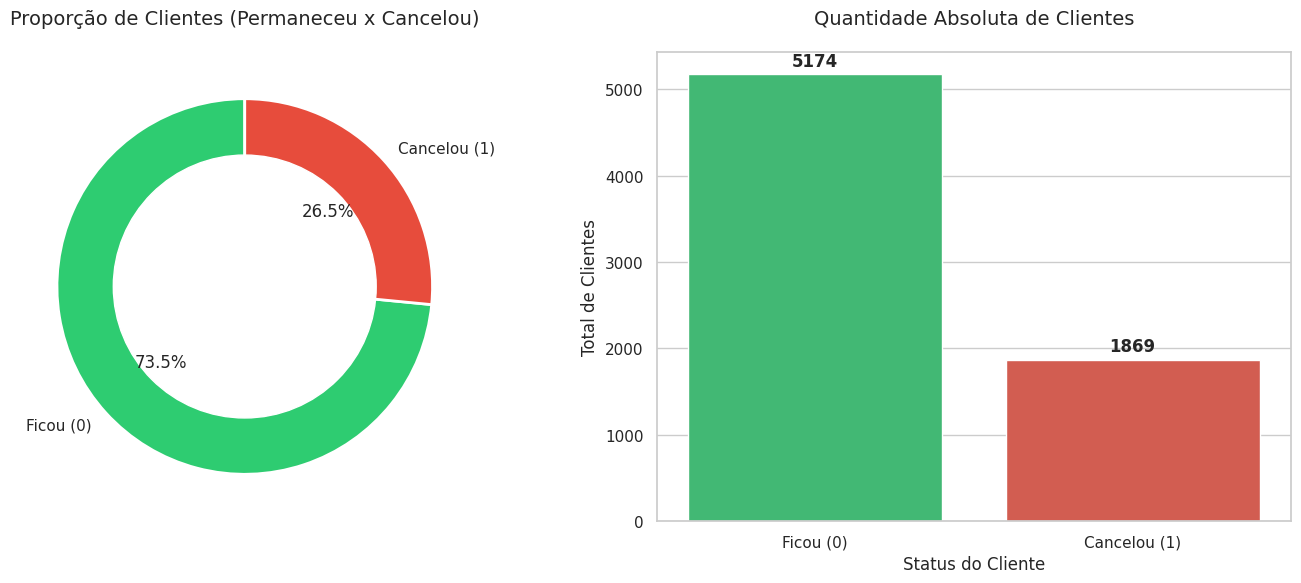

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Gerando visualização da distribuição de Churn (Evasão)...\n")


sns.set_theme(style="whitegrid")
cores = ['#2ecc71', '#e74c3c'] # Verde para Retidos (0), Vermelho para Evasão (1)
labels = ['Ficou (0)', 'Cancelou (1)']


valores_absolutos = df['Cancelou'].value_counts()
proporcoes = df['Cancelou'].value_counts(normalize=True) * 100


fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].pie(proporcoes, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=cores, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporção de Clientes (Permaneceu x Cancelou)', fontsize=14, pad=20)

circulo_central = plt.Circle((0,0), 0.70, fc='white')
axes[0].add_artist(circulo_central)


sns.barplot(x=valores_absolutos.index, y=valores_absolutos.values, palette=cores, ax=axes[1])
axes[1].set_title('Quantidade Absoluta de Clientes', fontsize=14, pad=20)
axes[1].set_xlabel('Status do Cliente')
axes[1].set_ylabel('Total de Clientes')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(labels)


for i, valor in enumerate(valores_absolutos.values):
    axes[1].text(i, valor + 50, str(valor), ha='center', va='bottom', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

## Contagem de Evasão por Variáveis Categóricas

Gerando painel de análise de Evasão por Categorias...



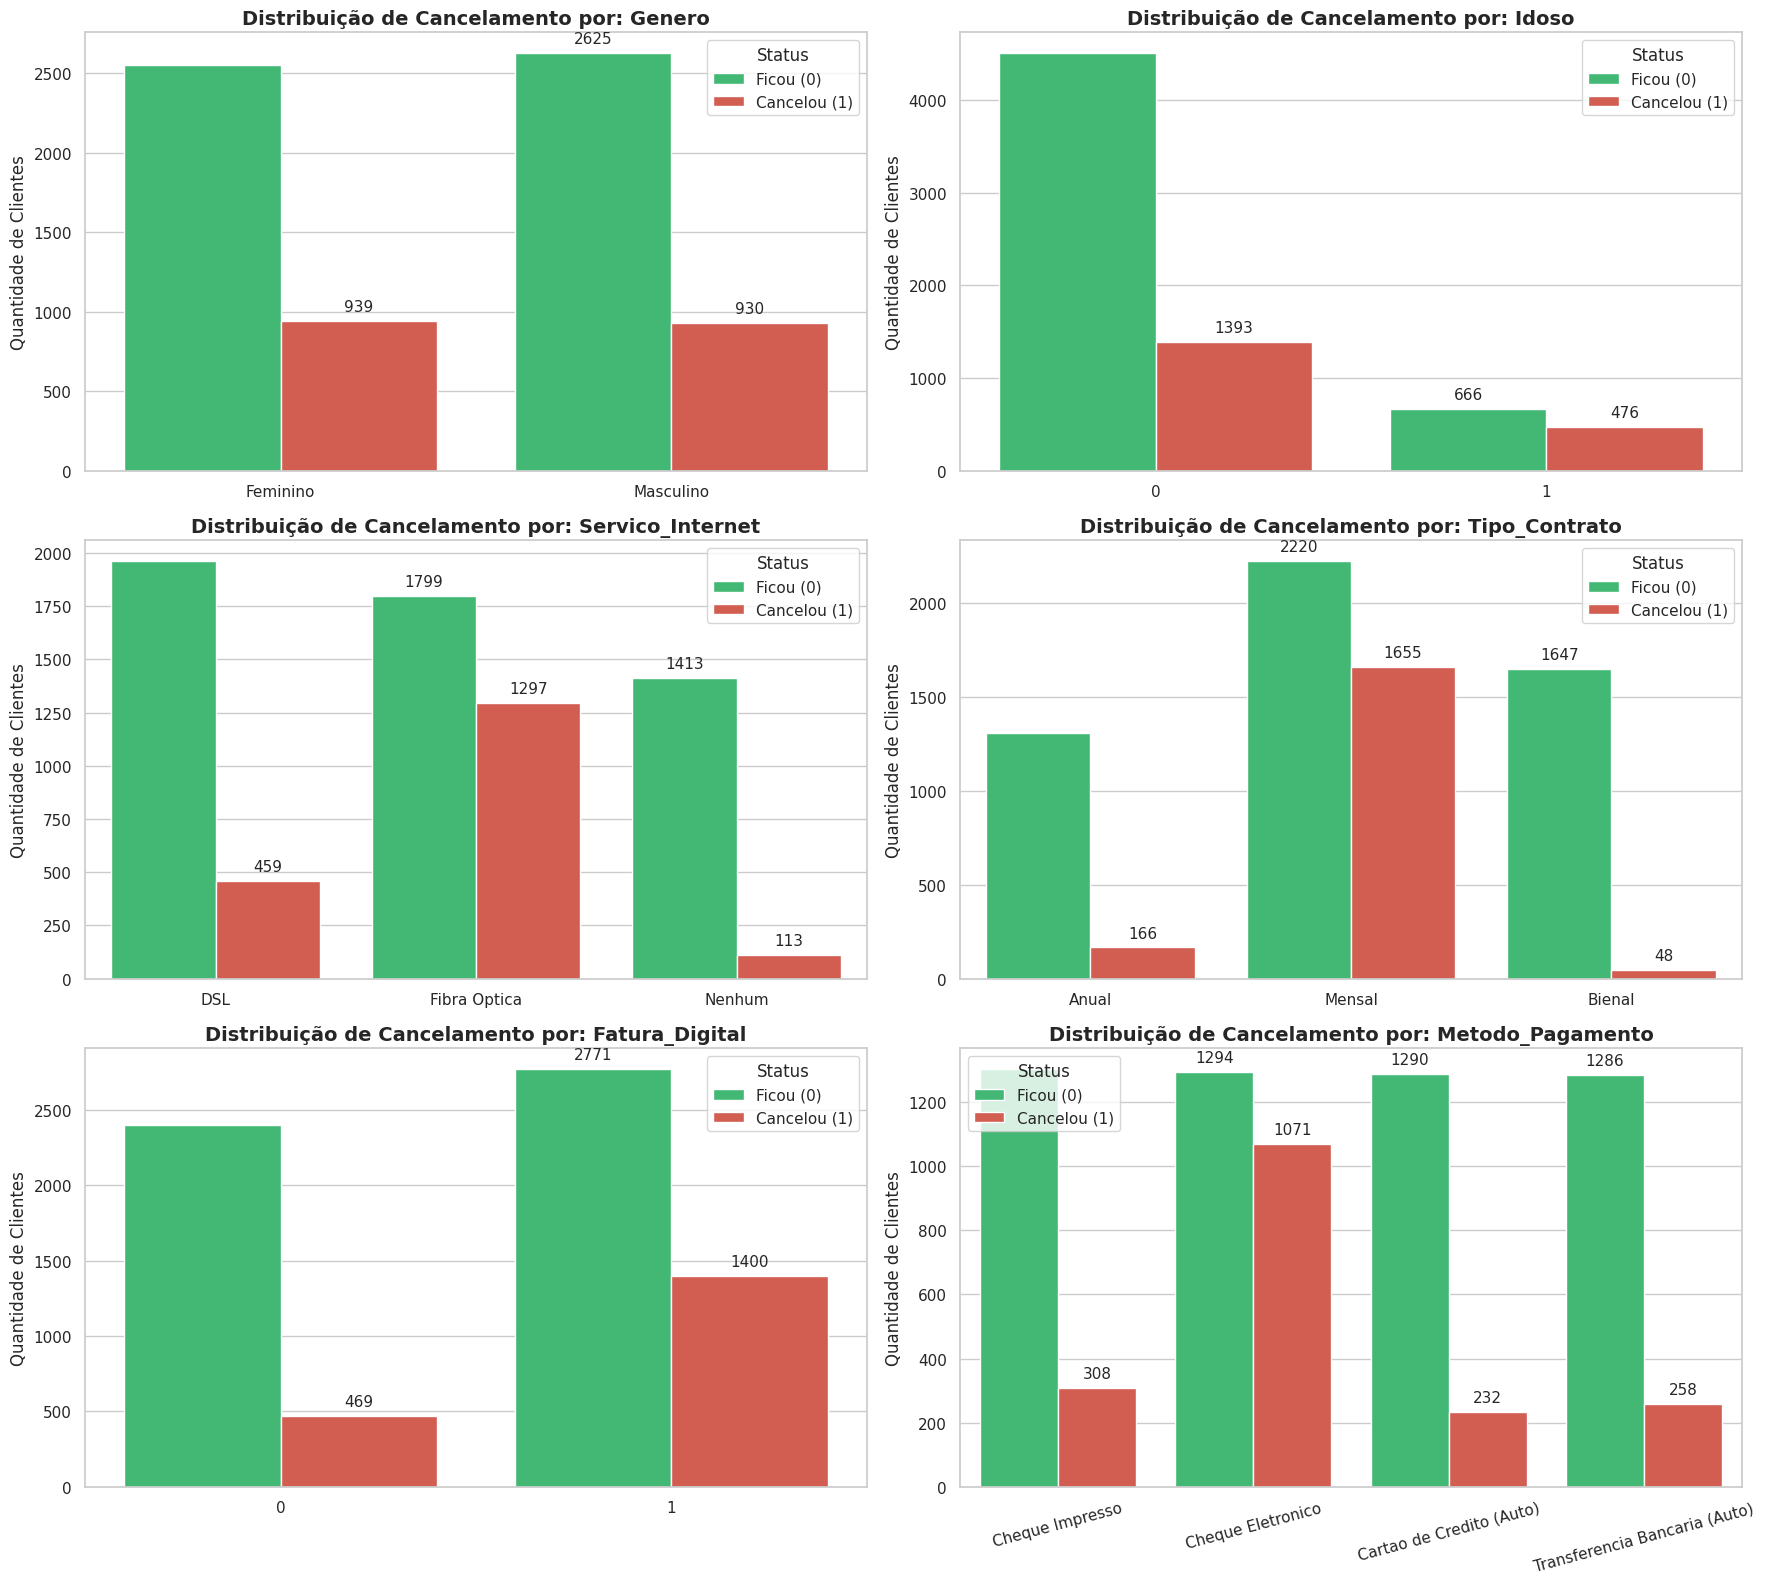

In [55]:


print("Gerando painel de análise de Evasão por Categorias...\n")


colunas_analise = ['Genero', 'Idoso', 'Servico_Internet', 'Tipo_Contrato', 'Fatura_Digital', 'Metodo_Pagamento']


sns.set_theme(style="whitegrid")
cores = ['#2ecc71', '#e74c3c'] # Verde (Ficou), Vermelho (Cancelou)


fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten() # Achata a matriz de eixos para facilitar o loop

for i, col in enumerate(colunas_analise):

    ax = sns.countplot(data=df, x=col, hue='Cancelou', palette=cores, ax=axes[i])


    axes[i].set_title(f'Distribuição de Cancelamento por: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Quantidade de Clientes')


    if col == 'Metodo_Pagamento':
        axes[i].tick_params(axis='x', rotation=15)


    legenda = axes[i].legend(title='Status')
    if legenda.get_texts():
        legenda.get_texts()[0].set_text('Ficou (0)')
        legenda.get_texts()[1].set_text('Cancelou (1)')


    totais = df[col].value_counts()

    for p in ax.patches:
        altura = p.get_height()

        if altura > 0 and p.get_x() > 0:
            ax.annotate(f'{int(altura)}',
                        (p.get_x() + p.get_width() / 2., altura),
                        ha='center', va='bottom', fontsize=11, xytext=(0, 5),
                        textcoords='offset points')


plt.tight_layout()
plt.show()

## Contagem de Evasão por Variáveis Numéricas

Analisando a distribuição das variáveis numéricas em relação à Evasão...



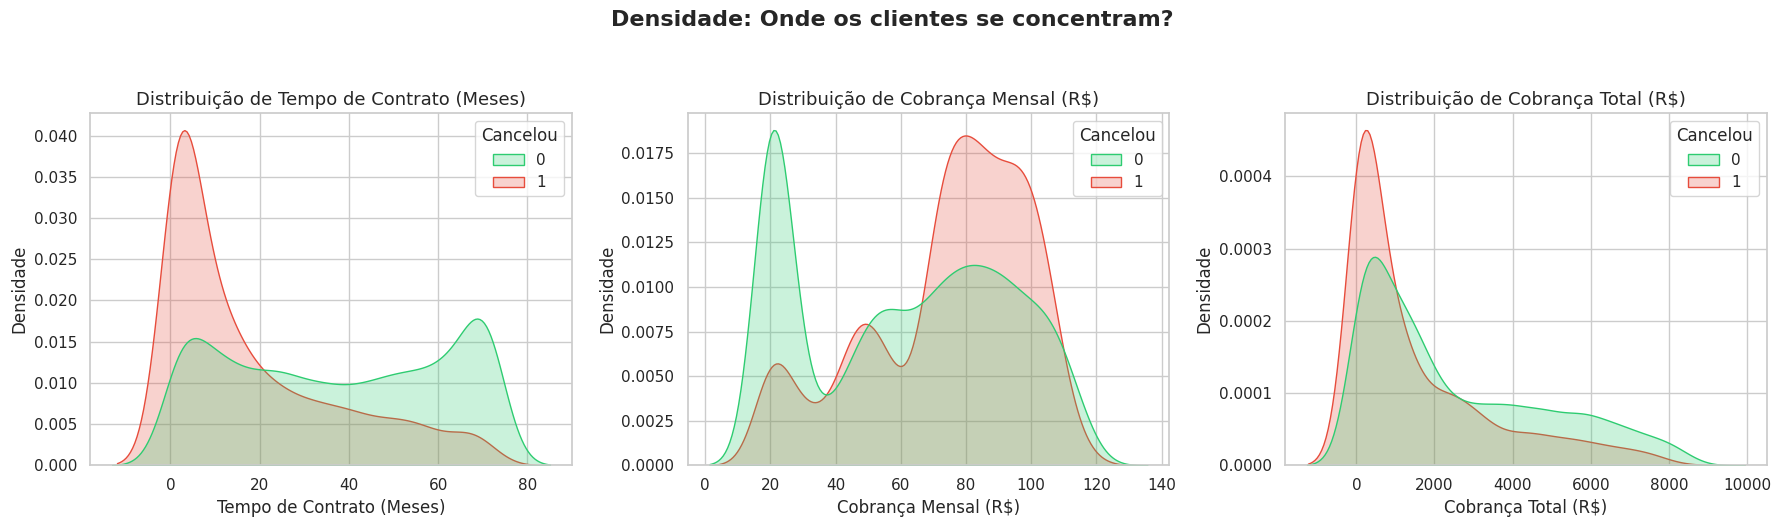

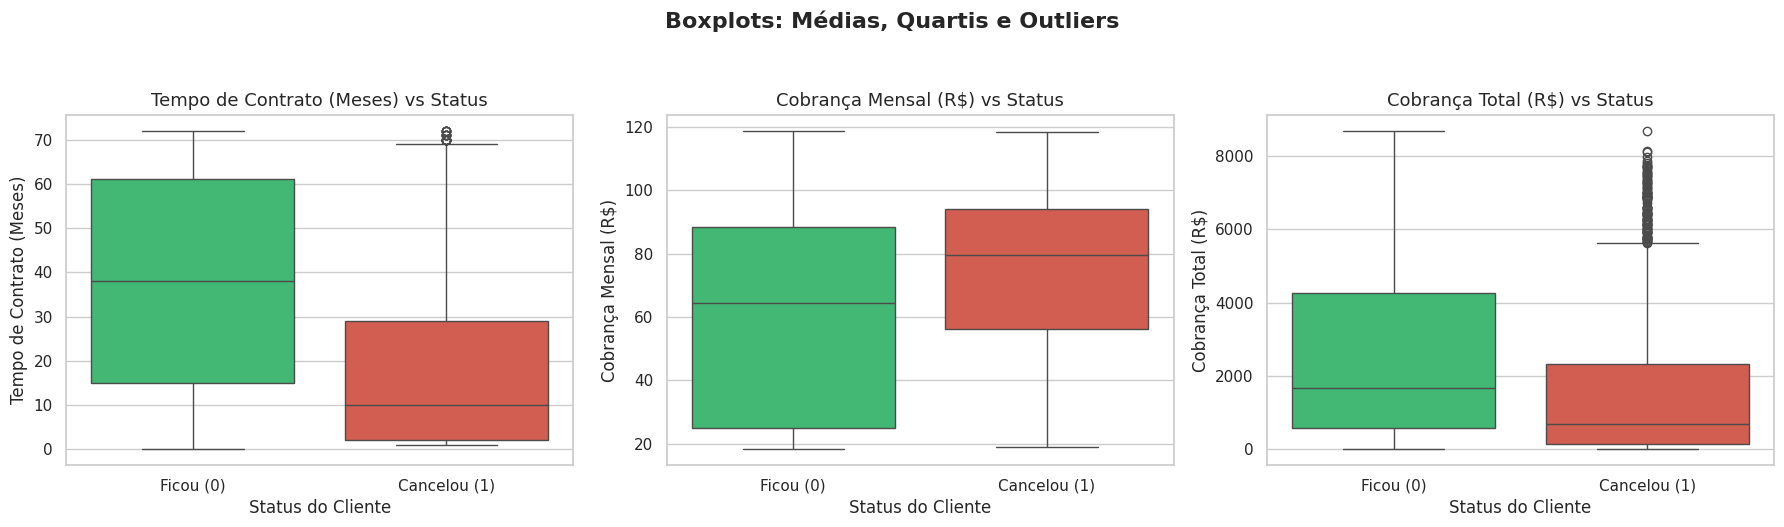

In [56]:


print("Analisando a distribuição das variáveis numéricas em relação à Evasão...\n")


colunas_num = ['Meses_Contrato', 'Cobranca_Mensal', 'Cobranca_Total']
titulos = ['Tempo de Contrato (Meses)', 'Cobrança Mensal (R$)', 'Cobrança Total (R$)']


sns.set_theme(style="whitegrid")


cores_dict = {0: '#2ecc71', 1: '#e74c3c', '0': '#2ecc71', '1': '#e74c3c'}


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Densidade: Onde os clientes se concentram?', fontsize=16, fontweight='bold', y=1.05)

for i, col in enumerate(colunas_num):
    sns.kdeplot(data=df, x=col, hue='Cancelou', fill=True, palette=cores_dict, ax=axes[i], common_norm=False)
    axes[i].set_title(f'Distribuição de {titulos[i]}', fontsize=13)
    axes[i].set_xlabel(titulos[i])
    axes[i].set_ylabel('Densidade')

plt.tight_layout()
plt.show()


fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('Boxplots: Médias, Quartis e Outliers', fontsize=16, fontweight='bold', y=1.05)

for i, col in enumerate(colunas_num):

    sns.boxplot(data=df, x='Cancelou', y=col, hue='Cancelou', palette=cores_dict, legend=False, ax=axes2[i])
    axes2[i].set_title(f'{titulos[i]} vs Status', fontsize=13)
    axes2[i].set_xlabel('Status do Cliente')
    axes2[i].set_ylabel(titulos[i])
    axes2[i].set_xticks([0, 1])
    axes2[i].set_xticklabels(['Ficou (0)', 'Cancelou (1)'])

plt.tight_layout()
plt.show()

# 📄Relatorio Final


## 1. Introdução
O presente projeto tem como objetivo analisar o comportamento dos clientes de uma empresa de telecomunicações para entender e mitigar o problema de **Churn (Evasão)**. O *Churn* representa a taxa de clientes que cancelam seus serviços em um determinado período. Reduzir essa métrica é fundamental, pois o custo de adquirir um novo cliente é significativamente maior do que reter um cliente atual. Nossa missão aqui foi identificar quais perfis e comportamentos estão mais associados ao cancelamento, fornecendo inteligência para a tomada de decisão.

## 2. Limpeza e Tratamento de Dados
Para garantir a confiabilidade das análises e preparar a base para futuros algoritmos de Machine Learning, uma rigorosa etapa de Engenharia de Dados foi aplicada:
* **Tratamento de Nulos e Inconsistências:** A variável alvo (`Cancelou`) possuía valores em branco, que foram removidos para não enviesar a análise. A coluna de `Cobranca_Total` foi convertida de texto para formato numérico (decimal), e os clientes novatos (com zero meses de contrato) tiveram seus valores preenchidos com `0`.
* **Redução de Dimensionalidade:** Categorias redundantes como `"Sem serviço de internet"` e `"Sem serviço de telefone"` foram simplificadas para `"Não"`.
* **Padronização e Tradução:** Todas as colunas e os dados internos foram traduzidos para o Português. Valores binários ("Sim"/"Não") foram convertidos para `1` e `0` (*Label Encoding*), otimizando o processamento matemático.
* **Feature Engineering:** Criamos uma nova variável chamada `Cobranca_Diaria` para obter uma granularidade maior sobre o gasto do cliente.

## 3. Análise Exploratória de Dados (EDA)
A exploração visual revelou padrões críticos no comportamento da base (composta por 7.043 clientes):
* **Taxa de Evasão:** Descobrimos que a taxa geral de cancelamento da empresa é de **27%**, um número que exige atenção imediata.
* **Análise Categórica:** Clientes com **contratos mensais** representam a esmagadora maioria das evasões. Além disso, assinantes do serviço de **Fibra Óptica** e os que utilizam **Cheque Eletrônico** como método de pagamento apresentam taxas de cancelamento desproporcionalmente altas. Por outro lado, o Gênero do cliente provou não ter impacto na decisão de ficar ou sair.
* **Análise Numérica:** Através de gráficos de densidade, ficou evidente que o pico de evasão ocorre nos **primeiros 5 meses de contrato**. Clientes que ultrapassam a barreira do primeiro ano tendem a se tornar fiéis. Observou-se também que clientes com **mensalidades mais altas** estão mais propensos ao cancelamento.

## 4. Conclusões e Insights
A análise dos dados nos permite concluir que o Churn não é aleatório; ele está fortemente concentrado em um perfil específico: **o cliente recente, sem fidelidade contratual, pagando altas mensalidades (frequentemente por Fibra Óptica) e utilizando métodos de pagamento manuais.** A falta de um "vínculo" forte (seja por um contrato anual ou pelo débito automático) facilita a saída desse cliente logo nas primeiras faturas, possivelmente devido a uma quebra de expectativa entre o preço pago e a qualidade percebida do serviço premium (Fibra Óptica).

## 5. Recomendações Estratégicas
Com base nos dados extraídos, sugerimos as seguintes ações para a equipe de Negócios e Retenção:

1. **Incentivo à Fidelização:** Criar campanhas agressivas de *upsell* oferecendo descontos na mensalidade para clientes que migrarem do plano "Mensal" para o "Anual" ou "Bienal".
2. **Foco no Onboarding (Primeiros Meses):** Como a evasão é massiva no início, a empresa deve implementar um programa de *Customer Success* dedicado aos primeiros 3 a 5 meses do cliente, garantindo que a instalação, o suporte e a experiência inicial sejam impecáveis.
3. **Investigação da Fibra Óptica:** É urgente abrir um chamado com a equipe de Engenharia/Produto para investigar se o serviço de Fibra Óptica está sofrendo com instabilidades técnicas ou se o preço está muito acima do valor de mercado, causando frustração.
4. **Transição de Método de Pagamento:** Oferecer benefícios (como *cashback* ou isenção de taxas) para clientes que cadastrarem o Cartão de Crédito ou Débito Automático, reduzindo o atrito do pagamento manual via Cheque Eletrônico.

#🎁​Extra : Análise de Correlação entre Variáveis

Iniciando a Análise Extra de Correlações...

-> [OK] Nova variável 'Total_Servicos' criada. Varia de 0 a 8 serviços por cliente.


/tmp/ipykernel_193/844297721.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_servico.index, y=churn_por_servico.values, palette='magma', ax=axes[1])


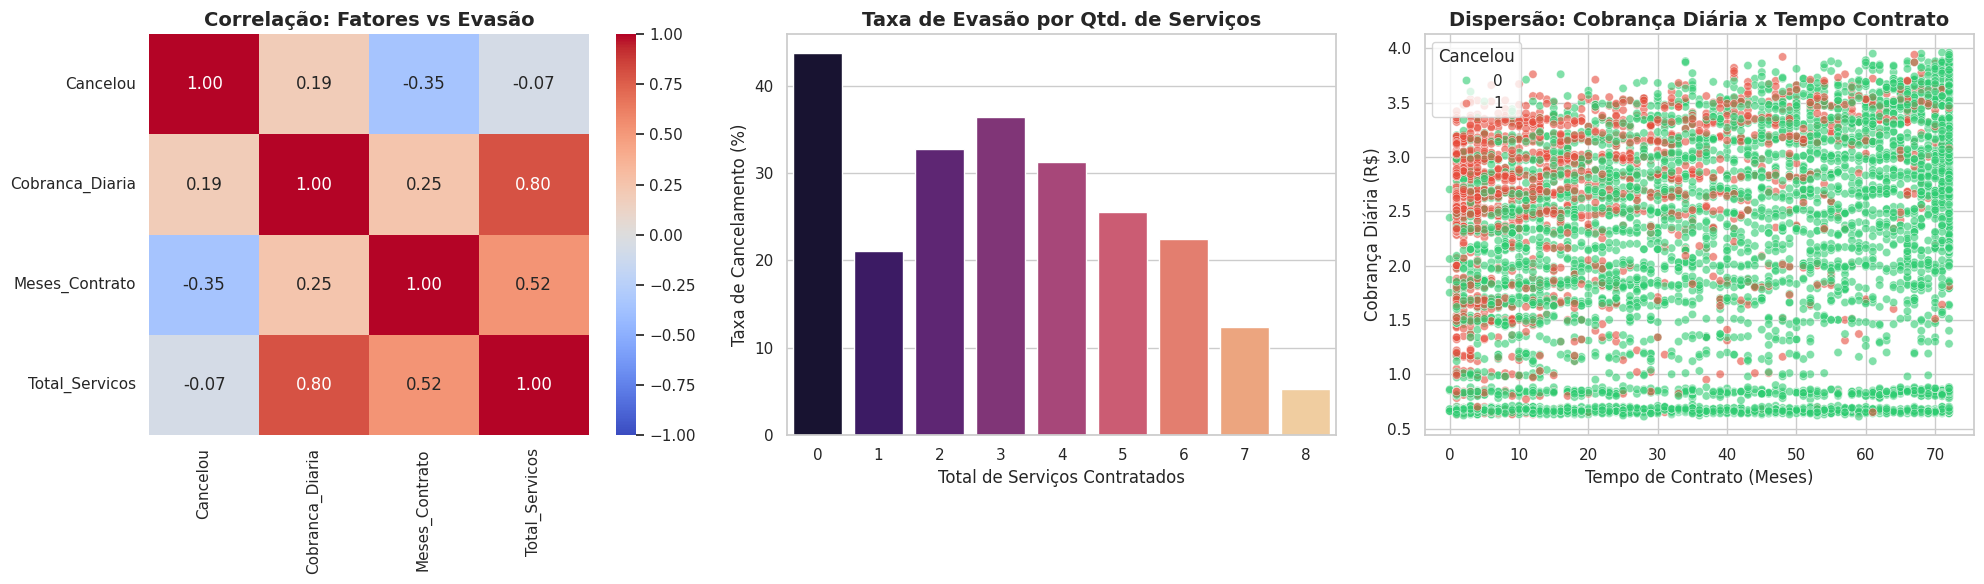

In [57]:

print("Iniciando a Análise Extra de Correlações...\n")


colunas_servicos = [
    'Servico_Telefone', 'Multiplas_Linhas', 'Seguranca_Online',
    'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico',
    'Streaming_TV', 'Streaming_Filmes'
]

df['Total_Servicos'] = df[colunas_servicos].sum(axis=1)
print(f"-> [OK] Nova variável 'Total_Servicos' criada. Varia de {df['Total_Servicos'].min()} a {df['Total_Servicos'].max()} serviços por cliente.")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.set_theme(style="whitegrid")


colunas_interesse = ['Cancelou', 'Cobranca_Diaria', 'Meses_Contrato', 'Total_Servicos']
matriz_corr = df[colunas_interesse].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlação: Fatores vs Evasão', fontsize=14, fontweight='bold')


churn_por_servico = df.groupby('Total_Servicos')['Cancelou'].mean() * 100

sns.barplot(x=churn_por_servico.index, y=churn_por_servico.values, palette='magma', ax=axes[1])
axes[1].set_title('Taxa de Evasão por Qtd. de Serviços', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total de Serviços Contratados')
axes[1].set_ylabel('Taxa de Cancelamento (%)')


cores_dict = {0: '#2ecc71', 1: '#e74c3c'}
sns.scatterplot(data=df, x='Meses_Contrato', y='Cobranca_Diaria', hue='Cancelou',
                palette=cores_dict, alpha=0.6, ax=axes[2])
axes[2].set_title('Dispersão: Cobrança Diária x Tempo Contrato', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tempo de Contrato (Meses)')
axes[2].set_ylabel('Cobrança Diária (R$)')


plt.tight_layout()
plt.show()